In [1]:
import numpy as np
from jax import numpy as jnp
import jax
import matplotlib.pyplot as plt

from blueprint.qubits import TunableTransmon, AnharmonicOscillator
from blueprint.devices import Device

import os, math

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90"  # for 90% of total GPU memory

# jax.config.update("jax_default_device", jax.devices("cpu")[0])
jax.config.update("jax_default_device", jax.devices("cuda")[0])
jax.config.update("jax_enable_x64", True)  # Double
dtype = jnp.complex128
# jax.config.update('jax_enable_x64', False) # Simple
# dtype = jnp.complex64

In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms, s = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi, 1e9 * 2 * math.pi

In [3]:
label = "Q1"
charging_energy = 0.17874386390652913 * GHz
josephson_energy = 28.045385714769342 * GHz
asymmetry = 0.617379794210013
charge_cutoff = 100
offset_charge = 0.0
ext_flux = 0.0
dim = 3

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
    relax_time=None,
    deph_time=None,
)
transmon.diagonalize(dim)

In [4]:
print(transmon.get_hamiltonian())

[[ 0.          0.          0.        ]
 [ 0.          6.14852788  0.        ]
 [ 0.          0.         12.10523746]]


In [5]:
device = Device([transmon,])
device.index_eigenstates()

In [6]:
print(device.get_hamiltonian())

[[ 0.          0.          0.        ]
 [ 0.          6.14852788  0.        ]
 [ 0.          0.         12.10523746]]


In [7]:
from blueprint.pulses import flux_pulses, coupler_pulses

In [8]:
device["Q1"].add_flux_drive(
    label="flux_Q1_cz_Q1_Q2", flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)

In [9]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843,  # 9.817191999999999,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

In [10]:
# fluxes = []
# for t in tsave:
#     fluxes.append(flux_pulses.net_zero_transition_flux_pulse(
#         t=t,
#         hold_first_voltage=-0.255,
#         transition_voltage=0.0,
#         half_hold_time=65.15 * 1 / 2,
#         transition_time=2.414131062723352,
#         buffer_start=1.9349107142857144e1,
#         buffer_end=1.9349107142857144e1,
#         flux_per_volt=3.1372549019607843,  # 9.817191999999999,  # free parameter that we want to optimize
#         gaussian_filter_sigma=0.5,
#     ))
# plt.plot(tsave, fluxes, '.-')

# dynamiqs

In [11]:
import dynamiqs as dq
from jax import Array

/home/gene2902/blueprint-env/lib/python3.11/site-packages/qutip/__init__.py:66: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


In [12]:
def build_dynamiqs_hamiltonian(device: Device):
    dq_hamiltonian = dq.constant(device.get_hamiltonian())
    for qubit in device.qubits:
        drives_iterator = qubit.get_drive_hamiltonian_terms()
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            print(dq_func(t=0.0))
            print(dq_func(t=40.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )

    for coupling_label, coupling in device._couplings.items():
        drives_iterator = coupling.get_drive_hamiltonian_terms()
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            # print(prefactor.free_params)
            print(dq_func(t=0.0))
            print(dq_func(t=40.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )
    return dq_hamiltonian

In [13]:
full_hamiltonian = build_dynamiqs_hamiltonian(device=device)

-0.0
8.505977321060394
-0.0
12.420772839508423


In [14]:
-transmon._ej * (np.cos(-0.8) - 1)

8.505977321060394

In [15]:
-transmon._ej * transmon._asymm * np.sin(-0.8)

12.420772839508423

In [16]:
full_hamiltonian(0.0)

Array([[ 0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  6.14852788+0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j, 12.10523746+0.j]],      dtype=complex128)

In [17]:
jnp.allclose(full_hamiltonian(0.0), device.get_hamiltonian())

Array(True, dtype=bool)

In [18]:
full_hamiltonian(30.0)

Array([[ 1.17194579e+01-1.08492283e-16j, -2.31635841e-15-3.99246907e+00j,
         9.69006794e-01+1.02385530e-15j],
       [-3.37864564e-15+3.99246907e+00j,  1.64643483e+01-8.24540727e-17j,
         4.43865743e-16-5.38347065e+00j],
       [ 9.69006794e-01-1.11499645e-15j, -3.94197709e-16+5.38347065e+00j,
         2.10140667e+01+2.91706556e-17j]], dtype=complex128)

In [19]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"]._op

[Array([[0. +0.j, 0.5+0.j, 0. +0.j, ..., 0. +0.j, 0. +0.j, 0. +0.j],
        [0.5+0.j, 0. +0.j, 0.5+0.j, ..., 0. +0.j, 0. +0.j, 0. +0.j],
        [0. +0.j, 0.5+0.j, 0. +0.j, ..., 0. +0.j, 0. +0.j, 0. +0.j],
        ...,
        [0. +0.j, 0. +0.j, 0. +0.j, ..., 0. +0.j, 0.5+0.j, 0. +0.j],
        [0. +0.j, 0. +0.j, 0. +0.j, ..., 0.5+0.j, 0. +0.j, 0.5+0.j],
        [0. +0.j, 0. +0.j, 0. +0.j, ..., 0. +0.j, 0.5+0.j, 0. +0.j]],      dtype=complex64),
 Array([[0.+0.j , 0.+0.5j, 0.+0.j , ..., 0.+0.j , 0.+0.j , 0.+0.j ],
        [0.-0.5j, 0.+0.j , 0.+0.5j, ..., 0.+0.j , 0.+0.j , 0.+0.j ],
        [0.+0.j , 0.-0.5j, 0.+0.j , ..., 0.+0.j , 0.+0.j , 0.+0.j ],
        ...,
        [0.+0.j , 0.+0.j , 0.+0.j , ..., 0.+0.j , 0.+0.5j, 0.+0.j ],
        [0.+0.j , 0.+0.j , 0.+0.j , ..., 0.-0.5j, 0.+0.j , 0.+0.5j],
        [0.+0.j , 0.+0.j , 0.+0.j , ..., 0.+0.j , 0.-0.5j, 0.+0.j ]],      dtype=complex64)]

In [20]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"]._prefactor_terms[0](t=70.0)

Array(8.50597732, dtype=float64)

In [21]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"]._prefactor_terms[1](t=70.0)

Array(-12.42077284, dtype=float64)

# Eigenenergies vs. time

In [22]:
from jax import scipy as jsp

In [23]:
# === tsave
tsave = jnp.linspace(0, 100, 101)

In [24]:
all_eigvals = []
for t in tsave:
    _hamil = full_hamiltonian(t)
    eig_vals, eig_vecs = jsp.linalg.eigh(_hamil, eigvals_only=False)
    norm_vals = eig_vals - eig_vals[0]
    all_eigvals.append(norm_vals)
all_eigvals = jnp.array(all_eigvals)

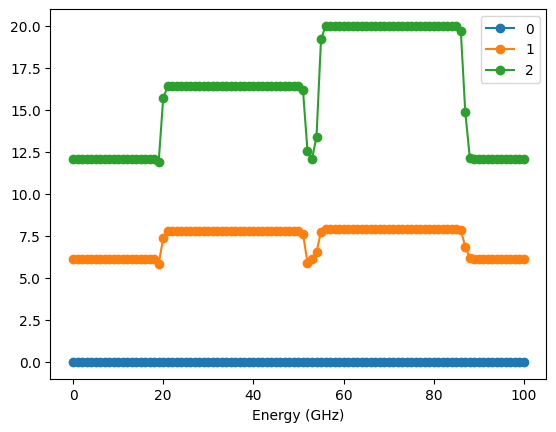

In [25]:
plt.plot(tsave, all_eigvals[:, 0], '-o', label='0')
plt.plot(tsave, all_eigvals[:, 1], "-o", label="1")
plt.plot(tsave, all_eigvals[:, 2], "-o", label="2")
plt.legend()
plt.xlabel("Time (ns)")
plt.xlabel("Energy (GHz)")
plt.show()

In [40]:
static_hamiltonian = transmon.get_hamiltonian()
all_eigvals = []
for t in tsave:
    drive_hamiltonian = transmon.get_drive_hamiltonian(t=t)
    full_hamiltonian = static_hamiltonian + drive_hamiltonian
    eig_vals = jsp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_vals = eig_vals - eig_vals[0]
    all_eigvals.append(norm_vals)
all_eigvals = jnp.array(all_eigvals)

In [41]:
all_eigvals.shape

(101, 3)

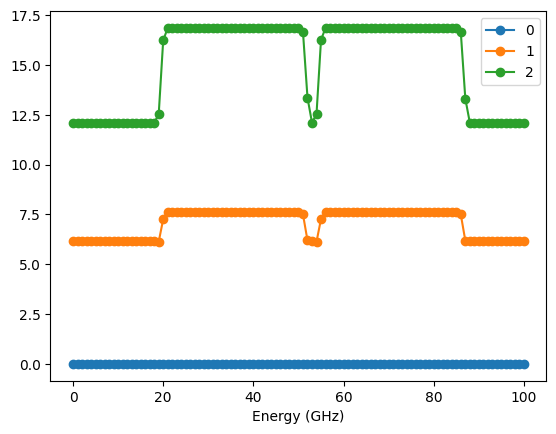

In [42]:
plt.plot(tsave, all_eigvals[:, 0], "-o", label="0")
plt.plot(tsave, all_eigvals[:, 1], "-o", label="1")
plt.plot(tsave, all_eigvals[:, 2], "-o", label="2")
plt.legend()
plt.xlabel("Time (ns)")
plt.xlabel("Energy (GHz)")
plt.show()

In [29]:
for drive in transmon._drives.values():
    drive_hamiltonian = drive.get_hamiltonian(t=40.0)
    print(drive_hamiltonian)

[[0.        +0.j         4.25298866+6.21038642j 0.        +0.j
  ... 0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [4.25298866-6.21038642j 0.        +0.j         4.25298866+6.21038642j
  ... 0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         4.25298866-6.21038642j 0.        +0.j
  ... 0.        +0.j         0.        +0.j
  0.        +0.j        ]
 ...
 [0.        +0.j         0.        +0.j         0.        +0.j
  ... 0.        +0.j         4.25298866+6.21038642j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  ... 4.25298866-6.21038642j 0.        +0.j
  4.25298866+6.21038642j]
 [0.        +0.j         0.        +0.j         0.        +0.j
  ... 0.        +0.j         4.25298866-6.21038642j
  0.        +0.j        ]]


In [30]:
transmon._get_drive_hamiltonian(t=40.0)

Array([[0.        +0.j        , 4.25298866+6.21038642j,
        0.        +0.j        , ..., 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [4.25298866-6.21038642j, 0.        +0.j        ,
        4.25298866+6.21038642j, ..., 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 4.25298866-6.21038642j,
        0.        +0.j        , ..., 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       ...,
       [0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , ..., 0.        +0.j        ,
        4.25298866+6.21038642j, 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , ..., 4.25298866-6.21038642j,
        0.        +0.j        , 4.25298866+6.21038642j],
       [0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , ..., 0.        +0.j        ,
 

In [31]:
transmon.drives["flux_Q1_cz_Q1_Q2"].param_vals

{'t': None,
 'hold_first_voltage': -0.255,
 'transition_voltage': 0.0,
 'half_hold_time': 32.575,
 'transition_time': 2.414131062723352,
 'buffer_start': 19.349107142857143,
 'buffer_end': 19.349107142857143,
 'flux_per_volt': 3.1372549019607843,
 'gaussian_filter_sigma': 0.5}

In [32]:
list(transmon.drives["flux_Q1_cz_Q1_Q2"].eval_prefactors(t=0.0))

[Array(-0., dtype=float64), Array(-0., dtype=float64)]

In [33]:
list(transmon.drives["flux_Q1_cz_Q1_Q2"].eval_prefactors(t=40.0))

[Array(8.50597732, dtype=float64), Array(12.42077284, dtype=float64)]

In [35]:
transmon.get_drive_hamiltonian(t=0.0)

Array([[0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j]], dtype=complex128)

In [36]:
transmon.process_op(transmon._get_drive_hamiltonian(t=0.0))

Array([[0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j]], dtype=complex128)

In [ ]:
# Do something dumb here because of the caching, will fix and improve later
ext_fluxes = np.linspace(-2*math.pi, 2*math.pi, 101)

all_eigvals = []

for idx, ext_flux in enumerate(ext_fluxes):
    transmon_1 = TunableTransmon(
        label="Q1",
        charging_energy=charging_energy,
        josephson_energy=josephson_energy,
        charge_cutoff=charge_cutoff,
        offset_charge=offset_charge,
        ext_flux=ext_flux,
        asymmetry=asymmetry,
        relax_time=None,
        deph_time=None,
    )
    transmon_1.diagonalize(dim)
    all_eigvals.append(transmon_1._eig_vals[:dim])
all_eigvals = jnp.array(all_eigvals)

In [ ]:
all_eigvals.shape

(101, 3)

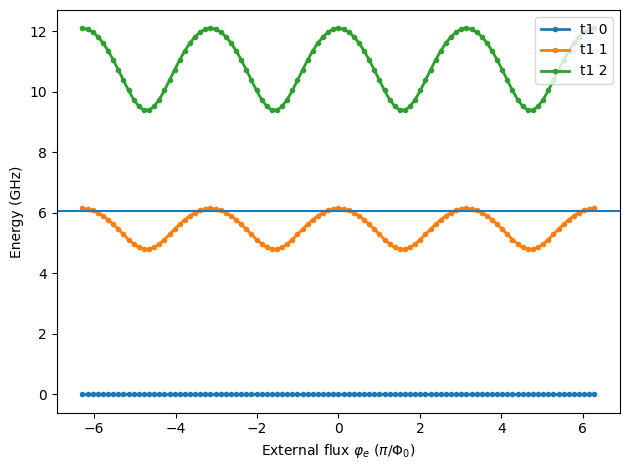

In [ ]:
markers = ".-"
lw = 2.0
plt.plot(ext_fluxes, all_eigvals[:, 0], markers, lw=lw, label=f"t1 0")
plt.plot(ext_fluxes, all_eigvals[:, 1], markers, lw=lw, label=f"t1 1")
plt.plot(ext_fluxes, all_eigvals[:, 2], markers, lw=lw, label=f"t1 2")

plt.axhline(6.067657949379383, ls="-", c="C0")
# plt.axhline(4.344903495992916, ls="-", c="C2")

plt.legend()
plt.xlabel(r"External flux $\varphi_e$ ($\pi/\Phi_0$)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

In [ ]:
def _get_potential_term(self) -> Array:
    """
    _get_potential_term Returns the potential term of the Hamiltonian in the charge basis.

    Returns
    -------
    Array
        The potential term of the transmon Hamiltonian expressed in the charge basis.
    """
    cosphi_op = self._get_cosphi_op()
    sinphi_op = self._get_sinphi_op()

    # phase = jnp.arctan(self._asymm * jnp.tan(self._ext_flux))

    cos_term = jnp.cos(self._ext_flux) * cosphi_op
    sin_term = (self._asymm * jnp.sin(self._ext_flux)) * sinphi_op

    potential_term = -self._ej * (cos_term + sin_term)
    return potential_term